In [13]:
import pandas as pd
import statistics

In [6]:
df = pd.read_csv('data/wine_cleared.csv')


>Вычислите наименьший балл за вино в датасете

In [11]:
print(f"Наименьший балл за вино в датасете - {df['points'].min()}")

Наименьший балл за вино в датасете - 80


>Вычислите наименьшую цену за бутылку в наборе данных

In [12]:
print(f"Наименьшая цена за бутылку вина - {df['price'].min()}")

Наименьшая цена за бутылку вина - 4.0


Далее мы рассмотрим наиболее популярные меры центральной тенденции, используемые в машинном обучении: среднее арифметическое, медиана, мода. Для расчёта этих описательных статистик в Python мы будем пользоваться библиотекой [statistics](https://docs.python.org/3/library/statistics.html). Она предоставляет готовые функции для вычисления математической статистики для числовых данных.

Установим библиотеку:
```python
pip install statistics
Импортируем библиотеку для дальнейшего использования:

import statistics

### <center> Среднее арифметическое

> **Среднее арифметическое** — сумма всех элементов, поделённая на количество элементов в числовом ряду или признаке (Series).

$Среднее арифметическое = \frac{Сумма  всех  чисел}{Количество  слагаемых}$

>Вычислите среднюю стоимость бутылки вина при помощи функции statistics.mean() библиотеки statistics. Округлите значение до сотых.

In [20]:
print(f"Средняя стоимость бутылки вина составляет {round(statistics.mean(df['price']),2)}")

Средняя стоимость бутылки вина составляет 35.36


>Вычислите среднюю стоимость бутылки вина при помощи стандартных функций Python.

In [24]:
mean = sum(df['price']) / len(df['price'])
print(round(mean,2))

35.36


### <center> МЕДИАНА

>**Медиана** — средний элемент распределения. Для расчёта медианы должно выполняться одно условие: числовой ряд должен быть предварительно отсортирован. Только так мы сможем корректно рассчитать средний элемент. Признак может быть отсортирован как по возрастанию, так и по убыванию. 

>Вычислите медиану стоимости бутылки вина при помощи функции statistics.median() библиотеки statistics. Округлите значение до сотых

In [28]:
print(f"Медианная стоимость бутылки вина - {round(statistics.median(df['price']),2)}")

Медианная стоимость бутылки вина - 28.0


In [35]:
count_price = len(df['price']) # количество записей цен
sorted_price = sorted(df['price']) # отсортированные цены

if count_price % 2: # при нечетном кол-ве элементов выбираем средний по индексу 
    median = sorted_price[round(0.5*(count_price-1))]
else: # при четном кол-ве элементов выбираем 2 средних по индексу и считаем между ними среднее арифметическое
    index = round(0.5 * count_price)
    median_ = 0.5 * (sorted_price[index-1] + sorted_price[index])
median

28.0

Также в библиотеке statistics есть функции, связанные с медианой, — функция [statistics.median_low()](https://docs.python.org/3/library/statistics.html#statistics.median_low) и функция [statistics.median_high](https://docs.python.org/3/library/statistics.html#statistics.median_high).

→ В случае, когда количество элементов в числовом ряду (серии) нечётное, функции возвращают то же, что и median().

В случае, когда количество элементов чётное, у нас получается два средних значения:
* median_low() возвращает меньшее из них;
* median_high() возвращает большее из них.

>Примечание. Если в вашем наборе данных есть пропущенные значения, функции библиотеки *statistics* в отличие от других методов (например *[np.median()](https://numpy.org/doc/stable/reference/generated/numpy.median.html)* из библиотеки *numpy*) будут автоматически игнорировать пропущенные значения, не выдавая ошибку.

### <center> МОДА

**Мода** — самое часто встречающееся значение в числовом или нечисловом ряду данных.

Чаще всего мода используется в нечисловых рядах. Например самая популярная порода собак, фильм года, лучшие рестораны вычисляются именно модой.

>Вычислите моду стоимости бутылки (самую часто встречающуюся цену) вина при помощи функции statistics.mode() библиотеки statistics. Округлите значение до сотых.

In [36]:
print(f"Мода стоимости бутылки - {round(statistics.mode(df['price']),2)}")

Мода стоимости бутылки - 35.36


Моду также можно вычислить при помощи ```statistics.multimode()```. В случае наличия нескольких модовых (популярных значений) функция ```statistics.mode()``` вернёт вам ошибку StatisticsError, а ```statistics.multimode()``` — список с всеми вычисленными модовыми значениями.

In [37]:
mode = round(df["price"].value_counts().index[0],2)
mode

35.36

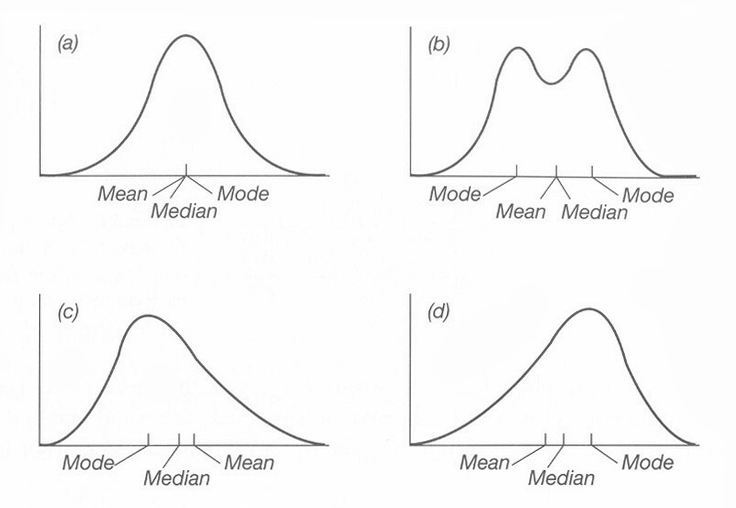

На этих схематических графиках показано, как могут выглядеть гистограммы с различными формами распределения. На графиках a и b — симметричные распределения, c и d — несимметричные.